## Клонируем репозиторий

In [2]:
%cd /kaggle/working
!git clone --branch main https://github.com/vputt/hw_dl.git
%cd /kaggle/working/hw_dl

/kaggle/working
Cloning into 'hw_dl'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 20 (delta 0), reused 20 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 1.48 MiB | 8.47 MiB/s, done.
/kaggle/working/hw_dl


## Устанавливаем зависимости

In [4]:
!pip install -q -r requirements-kaggle.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 4.5 MB/s eta 0:00:00


## W&B и путь к данным

In [11]:
import os
from pathlib import Path
from kaggle_secrets import UserSecretsClient

os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")

DATA_ROOT = Path(
    "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA"
)

TRAIN_PROTOCOL = (
    DATA_ROOT
    / "ASVspoof2019_LA_cm_protocols"
    / "ASVspoof2019.LA.cm.train.trn.txt"
)

print("Корень данных:", DATA_ROOT)
print("Корень существует:", DATA_ROOT.exists())
print("Train protocol существует:", TRAIN_PROTOCOL.exists())

os.environ["DATA_ROOT"] = str(DATA_ROOT)

Корень данных: /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA
Корень существует: True
Train protocol существует: True


## One-batch test перед обучением

Перед полным запуском выполняется обязательный one-batch test. Eval здесь отключён, потому что проверяется только способность модели переобучить один batch:

In [12]:
!python train.py \
    data.root="$DATA_ROOT" \
    data.num_workers=0 \
    debug.overfit_one_batch=true \
    trainer.monitor_eval=false \
    trainer.epochs=100 \
    scheduler.step_size=1000 \
    trainer.output_dir=/kaggle/working/one_batch_test \
    wandb.enabled=false

One-batch test: один и тот же batch используется для train и dev
Устройство: cuda | train: 25380 | dev: 24844 | параметров: 864,290
Epoch 001/100 | train CE=0.96553 | dev CE=1.03390 | dev EER=46.552% | best dev=46.552% (epoch 1)
Epoch 002/100 | train CE=0.77823 | dev CE=1.35500 | dev EER=35.632% | best dev=35.632% (epoch 2)
Epoch 003/100 | train CE=0.68208 | dev CE=0.89610 | dev EER=29.598% | best dev=29.598% (epoch 3)
Epoch 004/100 | train CE=0.62528 | dev CE=0.48581 | dev EER=16.954% | best dev=16.954% (epoch 4)
Epoch 005/100 | train CE=0.63634 | dev CE=0.42530 | dev EER=15.230% | best dev=15.230% (epoch 5)
Epoch 006/100 | train CE=0.61898 | dev CE=0.44100 | dev EER=12.644% | best dev=12.644% (epoch 6)
Epoch 007/100 | train CE=0.55374 | dev CE=0.44889 | dev EER=3.448% | best dev=3.448% (epoch 7)
Epoch 008/100 | train CE=0.50046 | dev CE=0.45916 | dev EER=12.644% | best dev=3.448% (epoch 7)
Epoch 009/100 | train CE=0.51117 | dev CE=0.40126 | dev EER=1.724% | best dev=1.724% (epoch 9)


## Полное обучение

Полный запуск выполняется с seed 42 и на 20 эпохах

В одной эпохе ожидается:

- 397 train batches при batch size 64
- 389 dev batches при batch size 64
- 557 eval batches при batch size 128

Полный eval содержит 71 237 записей

Eval EER считается после каждой эпохи только для графика. На выбор `best.pt` он не влияет. Checkpoint выбирается по минимальному dev EER, а при полном равенстве EER по меньшему dev loss


In [ ]:
!python train.py \
    data.root="$DATA_ROOT" \
    data.num_workers=2 \
    trainer.output_dir=/kaggle/working/lfcc_lcnn_ce_seed42

*после прогона wandb немного заспамил в вывод поэтому просто заскринила эпохи и отчистила вывод после запуска

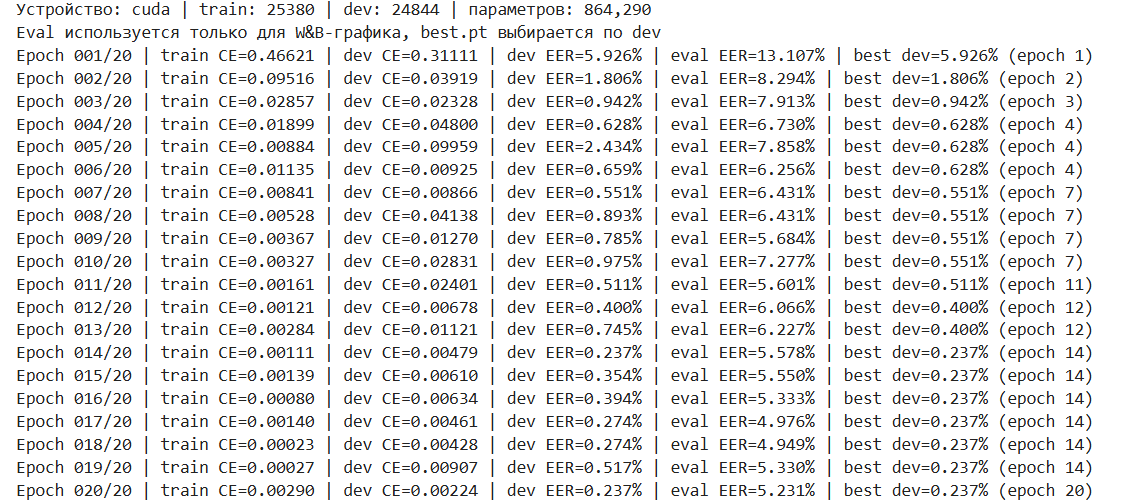
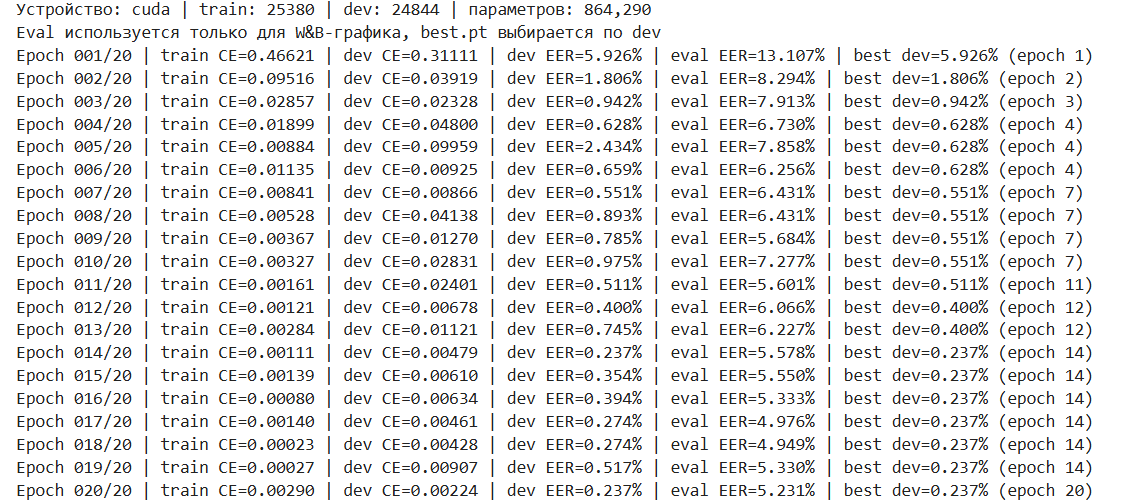

In [27]:
from pathlib import Path

checkpoint_dir = Path(
    "/kaggle/working/lfcc_lcnn_ce_seed42"
)

for name in ["best.pt", "last.pt", "epoch_020.pt"]:
    path = checkpoint_dir / name
    size = f"{path.stat().st_size / 1024**2:.1f} MB" if path.exists() else ""
    print(name, path.exists(), size)

best.pt True 10.0 MB
last.pt True 10.0 MB
epoch_020.pt True 10.0 MB


## Финальный inference

После обучения используется только `best.pt`:

In [16]:
!python inference.py \
    data.root="$DATA_ROOT" \
    inference.checkpoint=/kaggle/working/lfcc_lcnn_ce_seed42/best.pt \
    inference.output_path=/kaggle/working/vaputintseva.csv \
    inference.per_attack_output=/kaggle/working/vaputintseva_per_attack_eer.csv \
    inference.compute_eer=true

Сохранено 71237 строк в /kaggle/working/vaputintseva.csv; уникальных score: 71024
Eval EER: 5.2315% | threshold: 9.038194
EER по атакам сохранён в /kaggle/working/vaputintseva_per_attack_eer.csv


# **Итоговый eer по eval на best.pt: 5.2315%****


`inference.py` сразу проверяет число строк, порядок ключей и непрерывность scores. Если ошибка формата не появилась, запускаем выданный `grading.py`:

In [17]:
!mkdir -p students_solutions
!cp /kaggle/working/vaputintseva.csv students_solutions/vaputintseva.csv
!python grading.py

Grading complete. Results saved to /kaggle/working/hw_dl/grades.csv


## Графики

экспортируем из wandb csv по api

In [29]:
from pathlib import Path

import pandas as pd
import wandb

run_path = (
    "putinsevav-hse-university/"
    "voice-antispoofing/"
    "ufl4kmup"
)

remote_run = wandb.Api().run(run_path)

columns = [
    "epoch",
    "train/loss",
    "dev/loss",
    "eval/loss",
    "dev/eer_percent",
    "eval/eer_percent",
    "learning_rate",
]

rows = list(
    remote_run.scan_history(
        keys=columns,
        page_size=100,
    )
)

remote_history = (
    pd.DataFrame(rows)[columns]
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
    .reset_index(drop=True)
)

output_path = Path(
    "/kaggle/working/wandb_export_ufl4kmup.csv"
)

remote_history.to_csv(
    output_path,
    index=False,
)

print("Состояние:", remote_run.state)
print("Количество эпох:", len(remote_history))
print("Последняя эпоха:", remote_history["epoch"].max())
print("CSV сохранён:", output_path)
display(remote_history)

Состояние: finished
Количество эпох: 20
Последняя эпоха: 20
CSV сохранён: /kaggle/working/wandb_export_ufl4kmup.csv


,epoch,train/loss,dev/loss,eval/loss,dev/eer_percent,eval/eer_percent,learning_rate
0,1,0.466208,0.311109,0.770965,5.925523,13.106854,0.00030
1,2,0.095165,0.039192,0.664181,1.806418,8.294330,0.00030
2,3,0.028575,0.023276,0.788510,0.941894,7.913006,0.00030
3,4,0.018988,0.048004,1.276924,0.627929,6.729855,0.00030
4,5,0.008842,0.099592,1.710645,2.434348,7.858419,0.00030
5,6,0.011350,0.009245,0.749316,0.658765,6.255549,0.00030
6,7,0.008414,0.008663,0.813166,0.550560,6.430803,0.00030
7,8,0.005277,0.041376,0.403456,0.893118,6.430803,0.00030
8,9,0.003669,0.012702,0.815201,0.784912,5.684346,0.00030
9,10,0.003272,0.028309,0.829573,0.974973,7.277287,0.00030


In [31]:
!python /kaggle/working/hw_dl/plot_report.py \
  --history /kaggle/working/wandb_export_ufl4kmup.csv \
  --per-attack /kaggle/working/vaputintseva_per_attack_eer.csv \
  --output-dir /kaggle/working/report_figures

Выбран checkpoint эпохи 20: dev EER=0.2366%, eval EER=5.2315%
Графики сохранены в /kaggle/working/report_figures


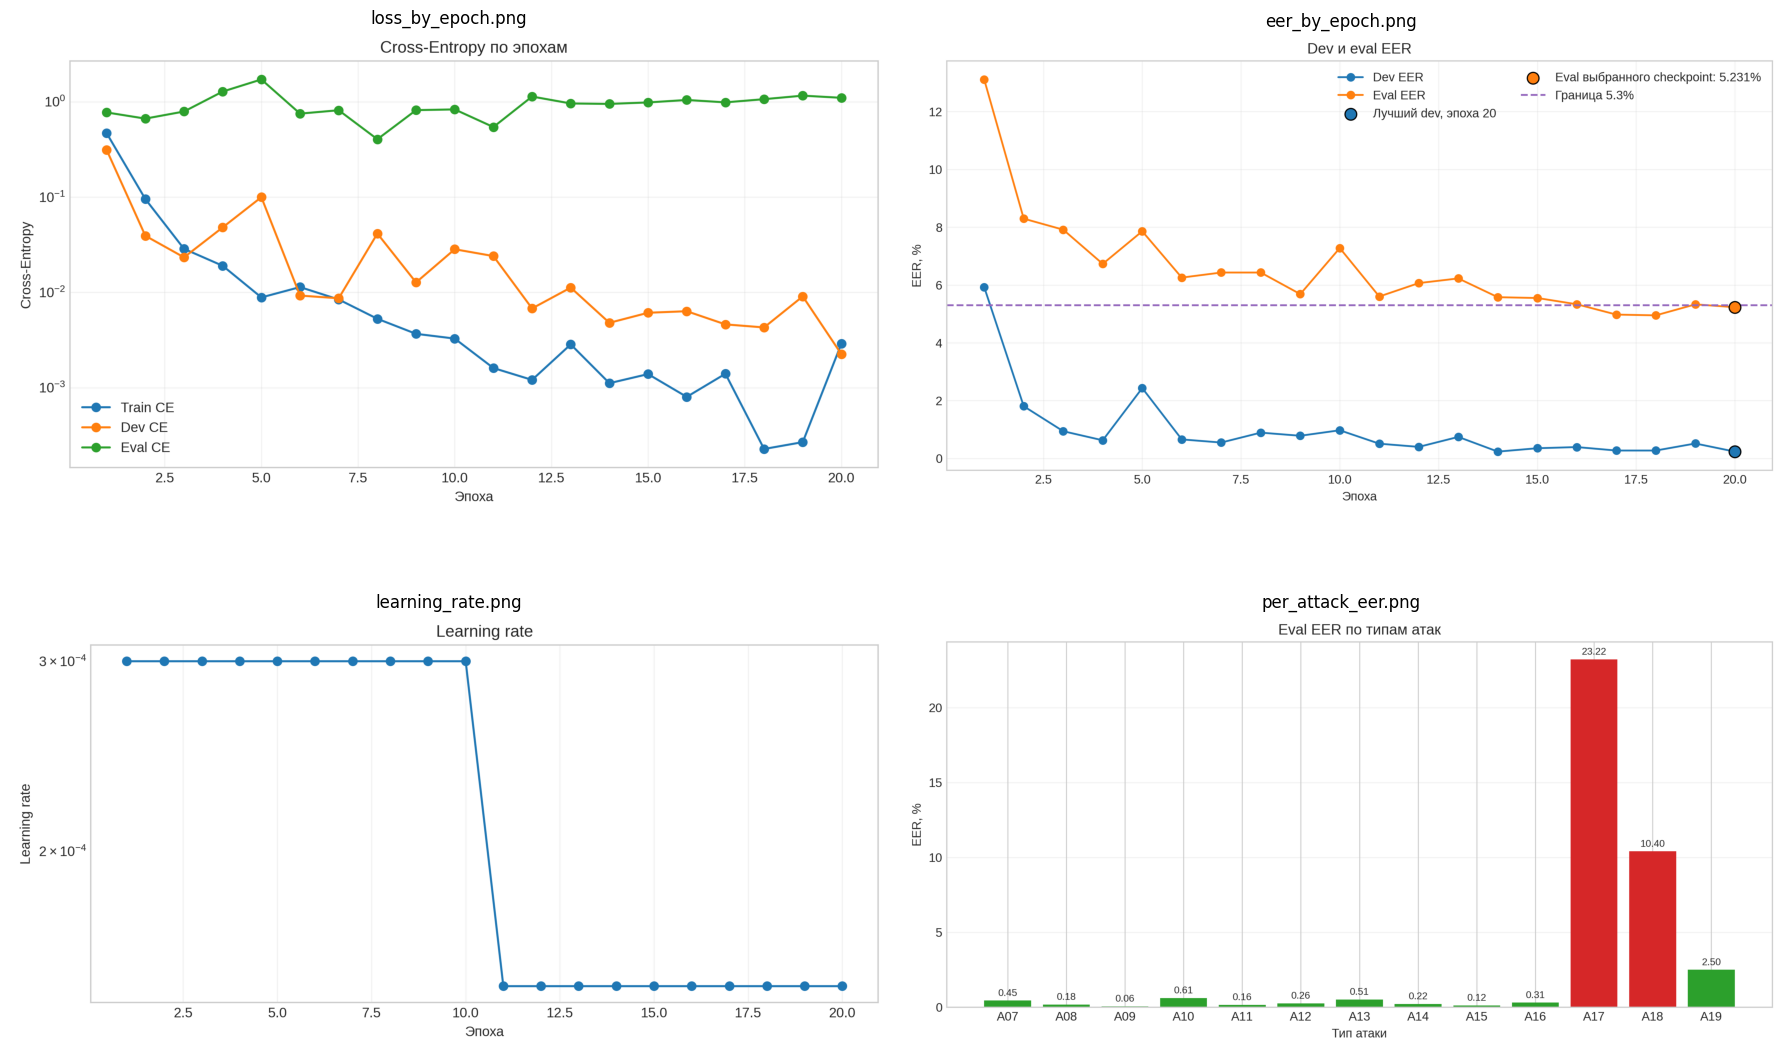

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

figure_dir = Path("/kaggle/working/report_figures")

figure_names = [
    "loss_by_epoch.png",
    "eer_by_epoch.png",
    "learning_rate.png",
    "per_attack_eer.png",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for axis, name in zip(axes.flat, figure_names):
    image = mpimg.imread(figure_dir / name)
    axis.imshow(image)
    axis.set_title(name)
    axis.axis("off")

plt.tight_layout()
plt.show()